In [1]:
# Importing necessary libraries for data preprocessing
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Importing necessary libraries for building and evaluating models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.losses import KLDivergence, MeanSquaredError

# Importing necessary libraries for saving and loading models
import joblib

In [2]:
df = pd.read_csv('KDDTrain+.txt', header=None)

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
#converting into five category 

df.replace(to_replace=["back", "neptune","pod", "smurf", "teardrop", "land"],
            value= "Dos", inplace= True)

df.replace(to_replace=["satan", "ipsweep","nmap", "portsweep"],
            value= "Probe", inplace= True)

df.replace(to_replace=["guess_passwd", "ftp_write","multihop", "imap", "warezmaster","phf", "spy", "warezclient"],
            value= "R2L", inplace= True)

df.replace(to_replace=["buffer_overflow", "rootkit","loadmodule", "perl"],
            value= "U2R", inplace= True)

In [5]:
df[41].unique()

array(['normal', 'Dos', 'R2L', 'Probe', 'U2R'], dtype=object)

In [6]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove(41)

In [7]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove(42)  # removing additional info column

In [8]:
# Define preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)])

In [9]:
# Applying ColumnTransformer
df_processed = preprocessor.fit_transform(df.drop(columns=[41, 42]))

In [10]:
df_processed = pd.DataFrame(df_processed)
df_processed

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121
0,0.000000,3.558064e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003914,0.003914,0.0,0.0,0.0,0.0,1.00,0.00,0.00,0.588235,0.098039,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.000000,1.057999e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025440,0.001957,0.0,0.0,0.0,0.0,0.08,0.15,0.00,1.000000,0.003922,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.240705,0.011742,1.0,1.0,0.0,0.0,0.05,0.07,0.00,1.000000,0.101961,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,1.681203e-07,6.223962e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.009785,0.009785,0.2,0.2,0.0,0.0,1.00,0.00,0.00,0.117647,1.000000,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.000000,1.442067e-07,3.206260e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.058708,0.062622,0.0,0.0,0.0,0.0,1.00,0.00,0.09,1.000000,1.000000,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.360078,0.048924,1.0,1.0,0.0,0.0,0.14,0.06,0.00,1.000000,0.098039,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [11]:
# Convert the target column to numeric
le = LabelEncoder()
df[41] = le.fit_transform(df[41])

In [12]:
# Extract target variable
y = df[41].values

In [13]:
# Check shape of preprocessed data
df_processed.shape, y.shape

((125973, 122), (125973,))

In [14]:
# Now, df_processed is the output from the last encoder. We can use this to train our XGBoost model.
X_train, X_test, y_train, y_test = train_test_split(df_processed, y, test_size=0.2, random_state=42)

***

In [15]:
# Intialize the LGBM model 
lgbm = LGBMClassifier(objective = 'multiclass', metric = 'multi_logloss', num_classes = 5, 
                      learning_rate = 0.01, max_depth =  50,  n_estimators = 770, num_leaves = 377)

### fit the grid searched model
%time lgbm.fit(X_train,y_train)

[LightGBM] [Warning] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029489 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3264
[LightGBM] [Info] Number of data points in the train set: 100778, number of used features: 110
[LightGBM] [Info] Start training from score -1.008891
[LightGBM] [Info] Start training from score -2.383013
[LightGBM] [Info] Start training from score -4.872987
[LightGBM] [Info] Start training from score -7.807103
[LightGBM] [Info] Start training from score -0.625400
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

LGBMClassifier(learning_rate=0.01, max_depth=50, metric='multi_logloss',
               n_estimators=770, num_classes=5, num_leaves=377,
               objective='multiclass')

In [16]:
# save the model to a file
#joblib.dump(lgbm_gridcv, 'lgbm_alone_gridsearch_five.joblib')

In [17]:
# Prediction on test dataset
%time y_pred_test = lgbm.predict(X_test)

# printing the predictions
print(y_pred_test)

CPU times: total: 1min 49s
Wall time: 1min
[4 0 0 ... 4 4 0]


In [18]:
# Keeping the positive probabilities only 
y_proba_test = lgbm.predict_proba(X_test)

In [19]:
# Print the classification report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9181
           1       1.00      1.00      1.00      2357
           2       0.99      0.99      0.99       224
           3       0.86      0.55      0.67        11
           4       1.00      1.00      1.00     13422

    accuracy                           1.00     25195
   macro avg       0.97      0.91      0.93     25195
weighted avg       1.00      1.00      1.00     25195



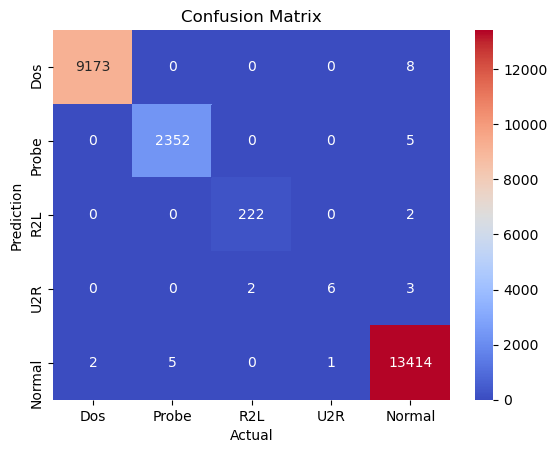

In [20]:
# Confusion matrix 
cm = confusion_matrix(y_test,y_pred_test)

# Plotting the confusion matrix 
sns.heatmap(cm,
            cmap = 'coolwarm',
            annot=True,
            fmt = "g",
            xticklabels=['Dos','Probe','R2L','U2R','Normal'],
            yticklabels=['Dos','Probe','R2L','U2R','Normal'])

plt.ylabel('Prediction')
plt.xlabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [21]:
# Compute the Multiclass ROC AUC score

lgbm_roc_score = roc_auc_score(y_test, y_proba_test, multi_class='ovr')
lgbm_roc_score

0.9997850324894915

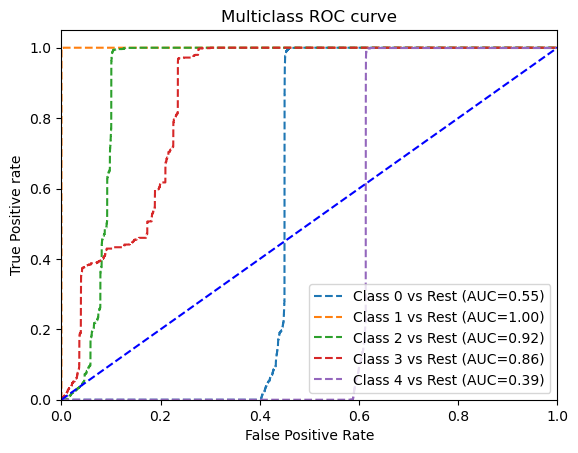

In [22]:
# roc curve for 5 classes
fpr = {}
tpr = {}
threshold ={}
n_class = 5
roc_auc = {}

for i in range(n_class): 
    fpr[i], tpr[i], threshold[i] = roc_curve(y_test, y_proba_test[:,i], pos_label = 1)
    roc_auc[i] = auc(fpr[i], tpr[i])
    # plotting    
    plt.plot(fpr[i], tpr[i], linestyle='--', label='Class {} vs Rest (AUC={:.2f})'.format(i, roc_auc[i]))

plt.plot([0,1],[0,1],'b--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='lower right')
plt.show()

****

In [23]:
# Predict the training time on train dataset
%time y_pred_train = lgbm.predict(X_train)

# printing the predictions
y_pred_train

CPU times: total: 7min 38s
Wall time: 4min 51s


array([4, 0, 0, ..., 0, 4, 4])

In [24]:
# Print the classification report for training dataset 
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     36746
           1       1.00      1.00      1.00      9299
           2       1.00      1.00      1.00       771
           3       1.00      1.00      1.00        41
           4       1.00      1.00      1.00     53921

    accuracy                           1.00    100778
   macro avg       1.00      1.00      1.00    100778
weighted avg       1.00      1.00      1.00    100778



In [25]:
def metrics(y_train, y_pred_train, y_test, y_pred_test):
    precision_train = precision_score(y_train, y_pred_train,average = 'macro')
    precision_test = precision_score(y_test, y_pred_test,average = 'macro')
    recall_train = recall_score(y_train, y_pred_train,average = 'macro')
    recall_test = recall_score(y_test, y_pred_test,average = 'macro')
    f1score_train = f1_score(y_train, y_pred_train,average = 'macro')
    f1score_test = f1_score(y_test, y_pred_test,average = 'macro')
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    metrics_dict = {
        "Precision (Train)": precision_train,
        "Precision (Test)": precision_test,
        "Recall (Train)": recall_train,
        "Recall (Test)": recall_test,
        "F1 Score (Train)": f1score_train,
        "F1 Score (Test)": f1score_test,
        "Accuracy (Train)": accuracy_train,
        "Accuracy (Test)": accuracy_test,
    }
    
    return metrics_dict

metrics(y_train, y_pred_train, y_test, y_pred_test)

{'Precision (Train)': 0.9999710765011827,
 'Precision (Test)': 0.9689069755985559,
 'Recall (Train)': 0.9997314447284517,
 'Recall (Test)': 0.9065874464410726,
 'F1 Score (Train)': 0.9998511758152381,
 'F1 Score (Test)': 0.930820755029309,
 'Accuracy (Train)': 0.9999702315981662,
 'Accuracy (Test)': 0.9988886683865846}

In [26]:
def metrics(y_train, y_pred_train, y_test, y_pred_test):
    precision_train = precision_score(y_train, y_pred_train,average = 'weighted')
    precision_test = precision_score(y_test, y_pred_test,average = 'weighted')
    recall_train = recall_score(y_train, y_pred_train,average = 'weighted')
    recall_test = recall_score(y_test, y_pred_test,average = 'weighted')
    f1score_train = f1_score(y_train, y_pred_train,average = 'weighted')
    f1score_test = f1_score(y_test, y_pred_test,average = 'weighted')
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)

    metrics_dict = {
        "Precision (Train)": precision_train,
        "Precision (Test)": precision_test,
        "Recall (Train)": recall_train,
        "Recall (Test)": recall_test,
        "F1 Score (Train)": f1score_train,
        "F1 Score (Test)": f1score_test,
        "Accuracy (Train)": accuracy_train,
        "Accuracy (Test)": accuracy_test,
    }
    
    return metrics_dict

metrics(y_train, y_pred_train, y_test, y_pred_test)

{'Precision (Train)': 0.9999702330331768,
 'Precision (Test)': 0.9988664681230597,
 'Recall (Train)': 0.9999702315981662,
 'Recall (Test)': 0.9988886683865846,
 'F1 Score (Train)': 0.9999702287158316,
 'F1 Score (Test)': 0.9988623353833049,
 'Accuracy (Train)': 0.9999702315981662,
 'Accuracy (Test)': 0.9988886683865846}

****

In [27]:
# Checking for overfitting

%time print('Training set score: {:.4f}'.format(lgbm.score(X_train, y_train)))

%time print('Test set score: {:.4f}'.format(lgbm.score(X_test, y_test)))

Training set score: 1.0000
CPU times: total: 8min 28s
Wall time: 5min 3s
Test set score: 0.9989
CPU times: total: 1min 58s
Wall time: 1min 2s


***

In [28]:
# Overall Detection Rate and False Alarm Rate

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

total_tp = 0
total_fn = 0
total_fp = 0
total_tn = 0
num_classes = 5

# Iterate over each class
for i in range(num_classes): 
    # Define the positive class as class i and the negative classes as all others
    selected_class = i
    all_other_classes = [c for c in range(num_classes) if c != selected_class]

    # Calculate True Positives (TP), False Negatives (FN), False Positives (FP), and True Negatives (TN)
    TP = cm[i, i]
    total_tp += TP
    FN = cm[i, all_other_classes].sum()
    total_fn += FN
    FP = cm[all_other_classes, i].sum()
    total_fp += FP
    TN = cm[all_other_classes, all_other_classes].sum() 
    total_tn += TN

overall_detection_rate = total_tp / (total_tp + total_fn)
overall_false_alarm_rate = total_fp / (total_fp + total_tn)
print('overall_detection_rate : ', overall_detection_rate * 100)  
print('overall_false_alarm_rate : ', overall_false_alarm_rate * 100)

overall_detection_rate :  99.88886683865846
overall_false_alarm_rate :  0.027806466989751328


In [29]:
# Detection Rate and False Alarm Rate for Each Class

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Initialize dictionaries to store results for each class
detection_rates = {}
false_alarm_rates = {}
class_accuracies = {}
num_classes = 5

# Iterate over each class
for i in range(num_classes): 
    # Define the positive class as class i and the negative classes as all others
    selected_class = i
    all_other_classes = [c for c in range(num_classes) if c != selected_class]

    # Calculate True Positives (TP), False Negatives (FN), False Positives (FP), and True Negatives (TN)
    TP = cm[i, i]
    FN = cm[i, all_other_classes].sum()
    FP = cm[all_other_classes, i].sum()
    TN = cm[all_other_classes, all_other_classes].sum()

    # Calculate Detection Rate (True Positive Rate) and False Alarm Rate for class i
    detection_rate = TP / (TP + FN)
    false_alarm_rate = FP / (FP + TN)
    
    # Calculate accuracy for class i
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    

    # Store the results in dictionaries
    detection_rates[f'Class_{i}'] = detection_rate
    false_alarm_rates[f'Class_{i}'] = false_alarm_rate
    class_accuracies[f'Class_{i}'] = accuracy
    
    # overall detection rate 
    
    
# Print the Detection Rates and False Alarm Rates for each class
for class_label, dr in detection_rates.items():
    print(f'Detection Rate for {class_label}: {dr:.4f}')
print('---------------------------------------------')

for class_label, far in false_alarm_rates.items():
    print(f'False Alarm Rate for {class_label}: {far:.4f}')
print('---------------------------------------------')

for class_label, acc in class_accuracies.items():
    print(f'Accuracy for {class_label}: {acc:.4f}')
print('---------------------------------------------')

Detection Rate for Class_0: 0.9991
Detection Rate for Class_1: 0.9979
Detection Rate for Class_2: 0.9911
Detection Rate for Class_3: 0.5455
Detection Rate for Class_4: 0.9994
---------------------------------------------
False Alarm Rate for Class_0: 0.0001
False Alarm Rate for Class_1: 0.0002
False Alarm Rate for Class_2: 0.0001
False Alarm Rate for Class_3: 0.0000
False Alarm Rate for Class_4: 0.0015
---------------------------------------------
Accuracy for Class_0: 0.9996
Accuracy for Class_1: 0.9996
Accuracy for Class_2: 0.9998
Accuracy for Class_3: 0.9998
Accuracy for Class_4: 0.9990
---------------------------------------------


***

***